# Análisis Exploratorio de Datos (EDA) - Olist E-Commerce

## Contexto del Negocio
Olist es una plataforma brasileña de e-commerce que conecta pequeños comercios con múltiples marketplaces. Este dataset contiene información de ~100k pedidos realizados entre 2016-2018 en múltiples marketplaces de Brasil.

## Objetivos del EDA
1. **Calidad de Datos**: Identificar nulos, duplicados, outliers y inconsistencias
2. **Estructura**: Validar relaciones entre tablas y claves foráneas
3. **Distribuciones**: Analizar patrones temporales, geográficos y de negocio
4. **Data Profiling**: Estadísticas descriptivas completas por tabla
5. **Hallazgos de Negocio**: Insights para stakeholders
6. **Recomendaciones ETL**: Definir reglas de transformación y limpieza

---

In [1]:
# ============================================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA) - OLIST E-COMMERCE
# ============================================================================
# Proyecto: Brazilian E-Commerce Public Dataset by Olist
# Analista: Data Analytics Team
# Fecha: Enero 2026
# Objetivo: Análisis exhaustivo de calidad, estructura y relaciones de datos
#          para diseñar un pipeline ETL robusto
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("="*80)
print("ANÁLISIS EXPLORATORIO DE DATOS - OLIST E-COMMERCE")
print("="*80)

ANÁLISIS EXPLORATORIO DE DATOS - OLIST E-COMMERCE


In [2]:
# ============================================================================
# SECCIÓN 1: CARGA Y OVERVIEW GENERAL DEL DATASET
# ============================================================================

# Diccionario para almacenar todos los datasets
datasets = {}
data_path = '../data/raw/'

# Lista de archivos a cargar
files = {
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

# Cargar todos los datasets
print("\nCARGANDO DATASETS...")
print("-" * 80)
for key, filename in files.items():
    datasets[key] = pd.read_csv(data_path + filename)
    print(f"✓ {key:20s}: {datasets[key].shape[0]:>8,} filas x {datasets[key].shape[1]:>2} columnas")

print("\n" + "="*80)


CARGANDO DATASETS...
--------------------------------------------------------------------------------
✓ orders              :   99,441 filas x  8 columnas
✓ order_items         :  112,650 filas x  7 columnas
✓ order_payments      :  103,886 filas x  5 columnas
✓ order_reviews       :   99,224 filas x  7 columnas
✓ customers           :   99,441 filas x  5 columnas
✓ products            :   32,951 filas x  9 columnas
✓ sellers             :    3,095 filas x  4 columnas
✓ geolocation         : 1,000,163 filas x  5 columnas
✓ category_translation:       71 filas x  2 columnas



In [3]:
# ============================================================================
# FUNCIÓN AUXILIAR: DATA PROFILING COMPLETO
# ============================================================================

def data_quality_report(df, dataset_name):
    """
    Genera un reporte completo de calidad de datos
    
    Parameters:
    -----------
    df : DataFrame
        Dataset a analizar
    dataset_name : str
        Nombre del dataset para el reporte
    """
    print("\n" + "="*80)
    print(f" REPORTE DE CALIDAD: {dataset_name.upper()}")
    print("="*80)
    
    # 1. Información general
    print(f"\n1️ INFORMACIÓN GENERAL")
    print(f"   • Filas: {df.shape[0]:,}")
    print(f"   • Columnas: {df.shape[1]}")
    print(f"   • Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # 2. Tipos de datos
    print(f"\n2️ TIPOS DE DATOS")
    type_counts = df.dtypes.value_counts()
    for dtype, count in type_counts.items():
        print(f"   • {str(dtype):15s}: {count} columnas")
    
    # 3. Valores nulos
    print(f"\n3️ VALORES NULOS")
    null_stats = pd.DataFrame({
        'Column': df.columns,
        'Nulls': df.isnull().sum(),
        'Null_%': (df.isnull().sum() / len(df) * 100).round(2)
    })
    null_stats = null_stats[null_stats['Nulls'] > 0].sort_values('Nulls', ascending=False)
    
    if len(null_stats) > 0:
        print(null_stats.to_string(index=False))
    else:
        print("   ✓ No hay valores nulos")
    
    # 4. Duplicados
    print(f"\n4️ DUPLICADOS")
    duplicates = df.duplicated().sum()
    dup_pct = (duplicates / len(df) * 100)
    print(f"   • Filas duplicadas: {duplicates:,} ({dup_pct:.2f}%)")
    
    # 5. Cardinalidad
    print(f"\n5️ CARDINALIDAD (Valores Únicos)")
    cardinality = pd.DataFrame({
        'Column': df.columns,
        'Unique': df.nunique(),
        'Unique_%': (df.nunique() / len(df) * 100).round(2)
    }).sort_values('Unique', ascending=False)
    print(cardinality.to_string(index=False))
    
    # 6. Columnas numéricas - estadísticas
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\n6️ ESTADÍSTICAS NUMÉRICAS")
        print(df[numeric_cols].describe().T)
    
    print("\n" + "-"*80)
    
    return null_stats, duplicates, cardinality

# Visualización de distribución de nulos
def plot_missing_values(df, title):
    """Visualiza el porcentaje de valores nulos por columna"""
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) > 0:
        plt.figure(figsize=(10, 6))
        missing_pct = (missing / len(df) * 100)
        missing_pct.plot(kind='barh', color='coral')
        plt.xlabel('Porcentaje de Nulos (%)')
        plt.title(f'Valores Nulos - {title}')
        plt.tight_layout()
        plt.show()
    else:
        print(f"✓ {title}: No hay valores nulos para visualizar")


 REPORTE DE CALIDAD: ORDERS

1️ INFORMACIÓN GENERAL
   • Filas: 99,441
   • Columnas: 8
   • Memoria: 52.94 MB

2️ TIPOS DE DATOS
   • object         : 8 columnas

3️ VALORES NULOS
                       Column  Nulls  Null_%
order_delivered_customer_date   2965    2.98
 order_delivered_carrier_date   1783    1.79
            order_approved_at    160    0.16

4️ DUPLICADOS
   • Filas duplicadas: 0 (0.00%)

5️ CARDINALIDAD (Valores Únicos)
                       Column  Unique  Unique_%
                     order_id   99441    100.00
                  customer_id   99441    100.00
     order_purchase_timestamp   98875     99.43
order_delivered_customer_date   95664     96.20
            order_approved_at   90733     91.24
 order_delivered_carrier_date   81018     81.47
order_estimated_delivery_date     459      0.46
                 order_status       8      0.01

--------------------------------------------------------------------------------

 ANÁLISIS ESPECÍFICO - ORDERS
-----------

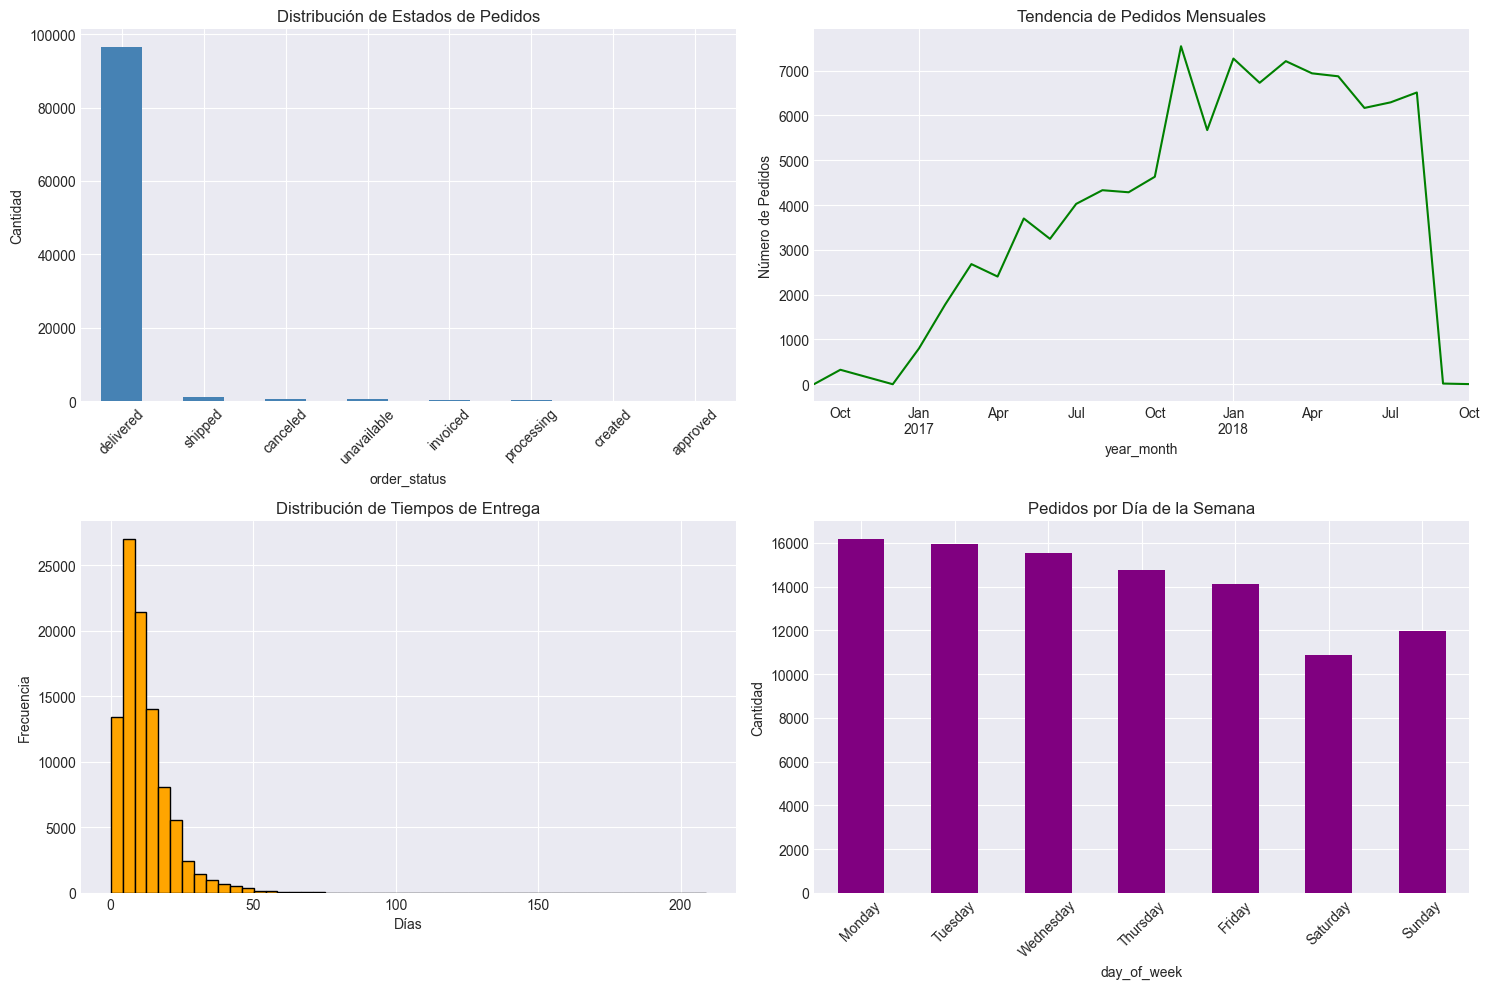


 HALLAZGOS CLAVE - ORDERS:
   1. Columnas de fecha requieren conversión a datetime en ETL
   2. Nulos en order_delivered_customer_date son pedidos cancelados/en tránsito (válidos)
   3. Detectados pedidos con retrasos en entrega - importante para KPIs de servicio
   4. Patrones estacionales visibles - útil para forecasting


In [4]:
# ============================================================================
# SECCIÓN 2: ANÁLISIS DETALLADO - ORDERS (Tabla Central)
# ============================================================================

df_orders = datasets['orders']
null_stats, dups, card = data_quality_report(df_orders, "Orders")

print("\n ANÁLISIS ESPECÍFICO - ORDERS")
print("-" * 80)

# Convertir columnas de fecha
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# Análisis de estados de pedidos
print("\n DISTRIBUCIÓN DE ESTADOS DE PEDIDOS")
status_dist = df_orders['order_status'].value_counts()
status_pct = (status_dist / len(df_orders) * 100).round(2)
status_df = pd.DataFrame({'Count': status_dist, 'Percentage': status_pct})
print(status_df)

# Análisis temporal
print("\n RANGO TEMPORAL")
print(f"   • Fecha inicio: {df_orders['order_purchase_timestamp'].min()}")
print(f"   • Fecha fin: {df_orders['order_purchase_timestamp'].max()}")
print(f"   • Período: {(df_orders['order_purchase_timestamp'].max() - df_orders['order_purchase_timestamp'].min()).days} días")

# Análisis de tiempos de entrega
df_orders['delivery_time_days'] = (df_orders['order_delivered_customer_date'] - 
                                     df_orders['order_purchase_timestamp']).dt.days

print("\n TIEMPOS DE ENTREGA (días)")
print(df_orders['delivery_time_days'].describe())

# Pedidos con problemas
delayed_orders = df_orders[df_orders['order_delivered_customer_date'] > 
                           df_orders['order_estimated_delivery_date']]
print(f"\n⚠️ PEDIDOS RETRASADOS: {len(delayed_orders):,} ({len(delayed_orders)/len(df_orders)*100:.2f}%)")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Estados de pedidos
status_dist.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribución de Estados de Pedidos')
axes[0,0].set_ylabel('Cantidad')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Pedidos por mes
df_orders['year_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df_orders['year_month'].value_counts().sort_index()
monthly_orders.plot(ax=axes[0,1], color='green')
axes[0,1].set_title('Tendencia de Pedidos Mensuales')
axes[0,1].set_ylabel('Número de Pedidos')

# 3. Distribución de tiempos de entrega
df_orders['delivery_time_days'].dropna().hist(bins=50, ax=axes[1,0], color='orange', edgecolor='black')
axes[1,0].set_title('Distribución de Tiempos de Entrega')
axes[1,0].set_xlabel('Días')
axes[1,0].set_ylabel('Frecuencia')

# 4. Pedidos por día de la semana
df_orders['day_of_week'] = df_orders['order_purchase_timestamp'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df_orders['day_of_week'].value_counts().reindex(day_order)
dow_counts.plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Pedidos por Día de la Semana')
axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n HALLAZGOS CLAVE - ORDERS:")
print("   1. Columnas de fecha requieren conversión a datetime en ETL")
print("   2. Nulos en order_delivered_customer_date son pedidos cancelados/en tránsito (válidos)")
print("   3. Detectados pedidos con retrasos en entrega - importante para KPIs de servicio")
print("   4. Patrones estacionales visibles - útil para forecasting")


 REPORTE DE CALIDAD: ORDER ITEMS

1️ INFORMACIÓN GENERAL
   • Filas: 112,650
   • Columnas: 7
   • Memoria: 35.99 MB

2️ TIPOS DE DATOS
   • object         : 4 columnas
   • float64        : 2 columnas
   • int64          : 1 columnas

3️ VALORES NULOS
   ✓ No hay valores nulos

4️ DUPLICADOS
   • Filas duplicadas: 0 (0.00%)

5️ CARDINALIDAD (Valores Únicos)
             Column  Unique  Unique_%
           order_id   98666     87.59
shipping_limit_date   93318     82.84
         product_id   32951     29.25
      freight_value    6999      6.21
              price    5968      5.30
          seller_id    3095      2.75
      order_item_id      21      0.02

6️ ESTADÍSTICAS NUMÉRICAS
                  count   mean    std  min   25%   50%    75%     max
order_item_id 112650.00   1.20   0.71 1.00  1.00  1.00   1.00   21.00
price         112650.00 120.65 183.63 0.85 39.90 74.99 134.90 6735.00
freight_value 112650.00  19.99  15.81 0.00 13.08 16.26  21.15  409.68

--------------------------

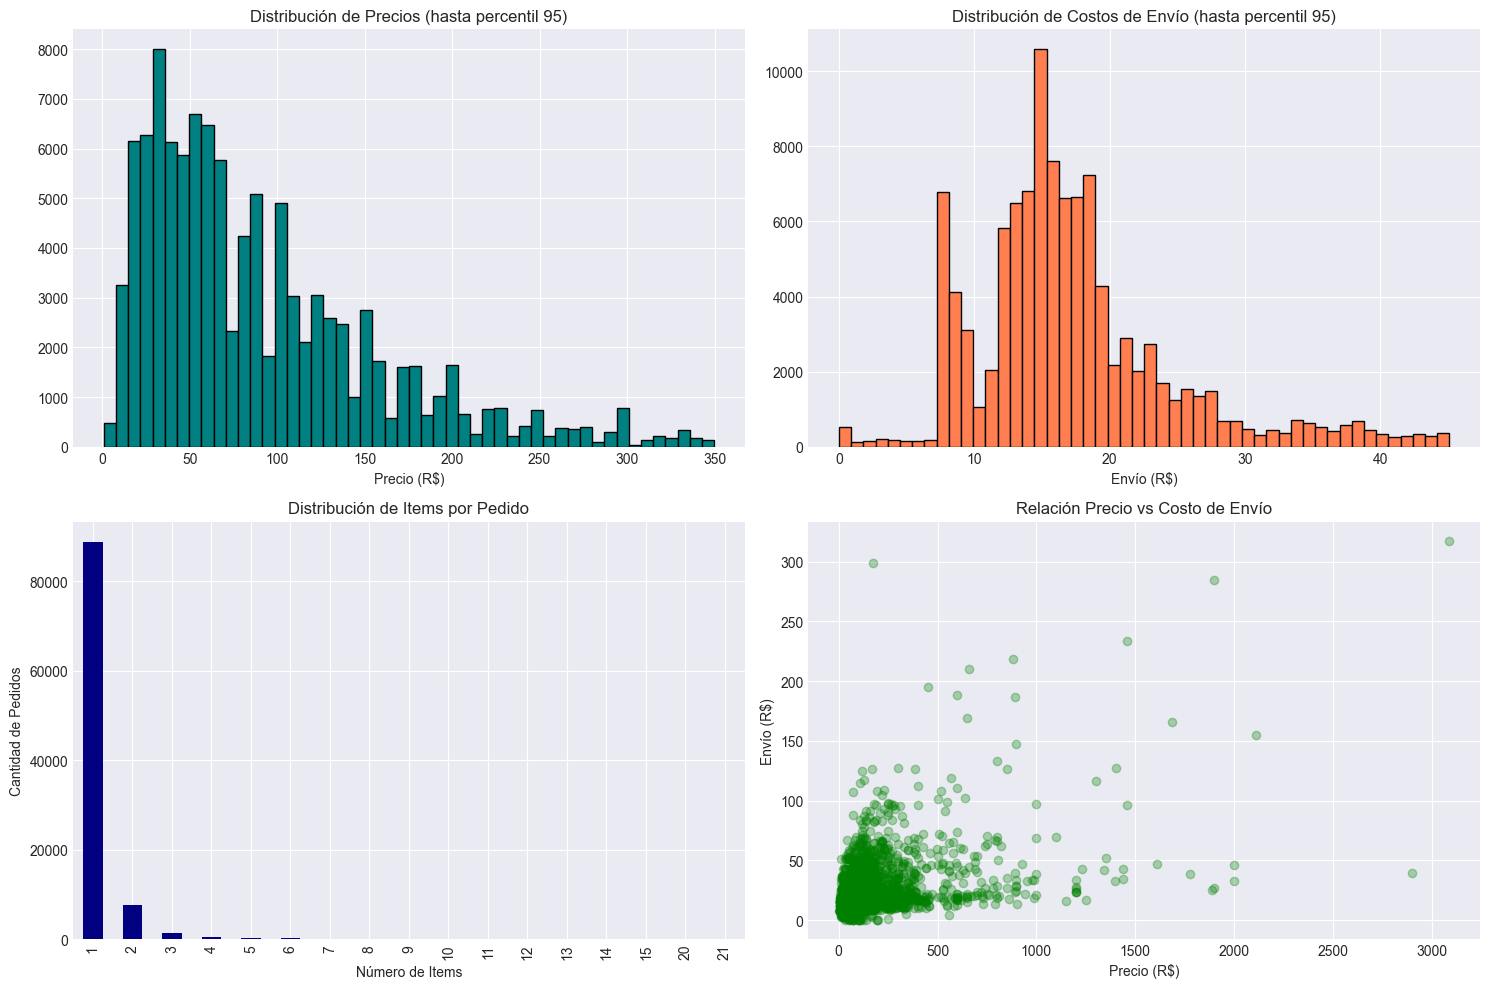


 HALLAZGOS CLAVE - ORDER ITEMS:
   1. Outliers significativos en precios - revisar si son errores o productos premium
   2. Mayoría de pedidos tienen 1 item - modelo de negocio importante
   3. Costos de envío representan una porción significativa del precio
   4. No hay valores nulos - dataset limpio


In [5]:
# ============================================================================
# SECCIÓN 3: ANÁLISIS DETALLADO - ORDER ITEMS
# ============================================================================

df_items = datasets['order_items']
null_stats, dups, card = data_quality_report(df_items, "Order Items")

print("\n ANÁLISIS ESPECÍFICO - ORDER ITEMS")
print("-" * 80)

# Análisis de precios
print("\n ANÁLISIS DE PRECIOS")
print(f"   • Precio promedio: R$ {df_items['price'].mean():.2f}")
print(f"   • Precio mediano: R$ {df_items['price'].median():.2f}")
print(f"   • Precio mínimo: R$ {df_items['price'].min():.2f}")
print(f"   • Precio máximo: R$ {df_items['price'].max():.2f}")

# Análisis de costos de envío
print("\n ANÁLISIS DE COSTOS DE ENVÍO")
print(f"   • Envío promedio: R$ {df_items['freight_value'].mean():.2f}")
print(f"   • Envío mediano: R$ {df_items['freight_value'].median():.2f}")
print(f"   • Ratio envío/precio: {(df_items['freight_value'].sum() / df_items['price'].sum() * 100):.2f}%")

# Items por pedido
items_per_order = df_items.groupby('order_id').size()
print("\n ITEMS POR PEDIDO")
print(items_per_order.describe())

# Outliers en precios
Q1 = df_items['price'].quantile(0.25)
Q3 = df_items['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_items[(df_items['price'] < Q1 - 1.5*IQR) | (df_items['price'] > Q3 + 1.5*IQR)]
print(f"\n⚠️ OUTLIERS EN PRECIOS: {len(outliers):,} ({len(outliers)/len(df_items)*100:.2f}%)")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribución de precios (sin outliers extremos)
df_items[df_items['price'] < df_items['price'].quantile(0.95)]['price'].hist(
    bins=50, ax=axes[0,0], color='teal', edgecolor='black')
axes[0,0].set_title('Distribución de Precios (hasta percentil 95)')
axes[0,0].set_xlabel('Precio (R$)')

# 2. Distribución de costos de envío
df_items[df_items['freight_value'] < df_items['freight_value'].quantile(0.95)]['freight_value'].hist(
    bins=50, ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Distribución de Costos de Envío (hasta percentil 95)')
axes[0,1].set_xlabel('Envío (R$)')

# 3. Items por pedido
items_per_order.value_counts().sort_index().head(20).plot(kind='bar', ax=axes[1,0], color='navy')
axes[1,0].set_title('Distribución de Items por Pedido')
axes[1,0].set_xlabel('Número de Items')
axes[1,0].set_ylabel('Cantidad de Pedidos')

# 4. Relación precio vs envío
sample = df_items.sample(min(5000, len(df_items)))
axes[1,1].scatter(sample['price'], sample['freight_value'], alpha=0.3, color='green')
axes[1,1].set_title('Relación Precio vs Costo de Envío')
axes[1,1].set_xlabel('Precio (R$)')
axes[1,1].set_ylabel('Envío (R$)')

plt.tight_layout()
plt.show()

print("\n HALLAZGOS CLAVE - ORDER ITEMS:")
print("   1. Outliers significativos en precios - revisar si son errores o productos premium")
print("   2. Mayoría de pedidos tienen 1 item - modelo de negocio importante")
print("   3. Costos de envío representan una porción significativa del precio")
print("   4. No hay valores nulos - dataset limpio")


 REPORTE DE CALIDAD: ORDER PAYMENTS

1️ INFORMACIÓN GENERAL
   • Filas: 103,886
   • Columnas: 5
   • Memoria: 16.23 MB

2️ TIPOS DE DATOS
   • object         : 2 columnas
   • int64          : 2 columnas
   • float64        : 1 columnas

3️ VALORES NULOS
   ✓ No hay valores nulos

4️ DUPLICADOS
   • Filas duplicadas: 0 (0.00%)

5️ CARDINALIDAD (Valores Únicos)
              Column  Unique  Unique_%
            order_id   99440     95.72
       payment_value   29077     27.99
  payment_sequential      29      0.03
payment_installments      24      0.02
        payment_type       5      0.00

6️ ESTADÍSTICAS NUMÉRICAS
                         count   mean    std  min   25%    50%    75%      max
payment_sequential   103886.00   1.09   0.71 1.00  1.00   1.00   1.00    29.00
payment_installments 103886.00   2.85   2.69 0.00  1.00   1.00   4.00    24.00
payment_value        103886.00 154.10 217.49 0.00 56.79 100.00 171.84 13664.08

---------------------------------------------------------

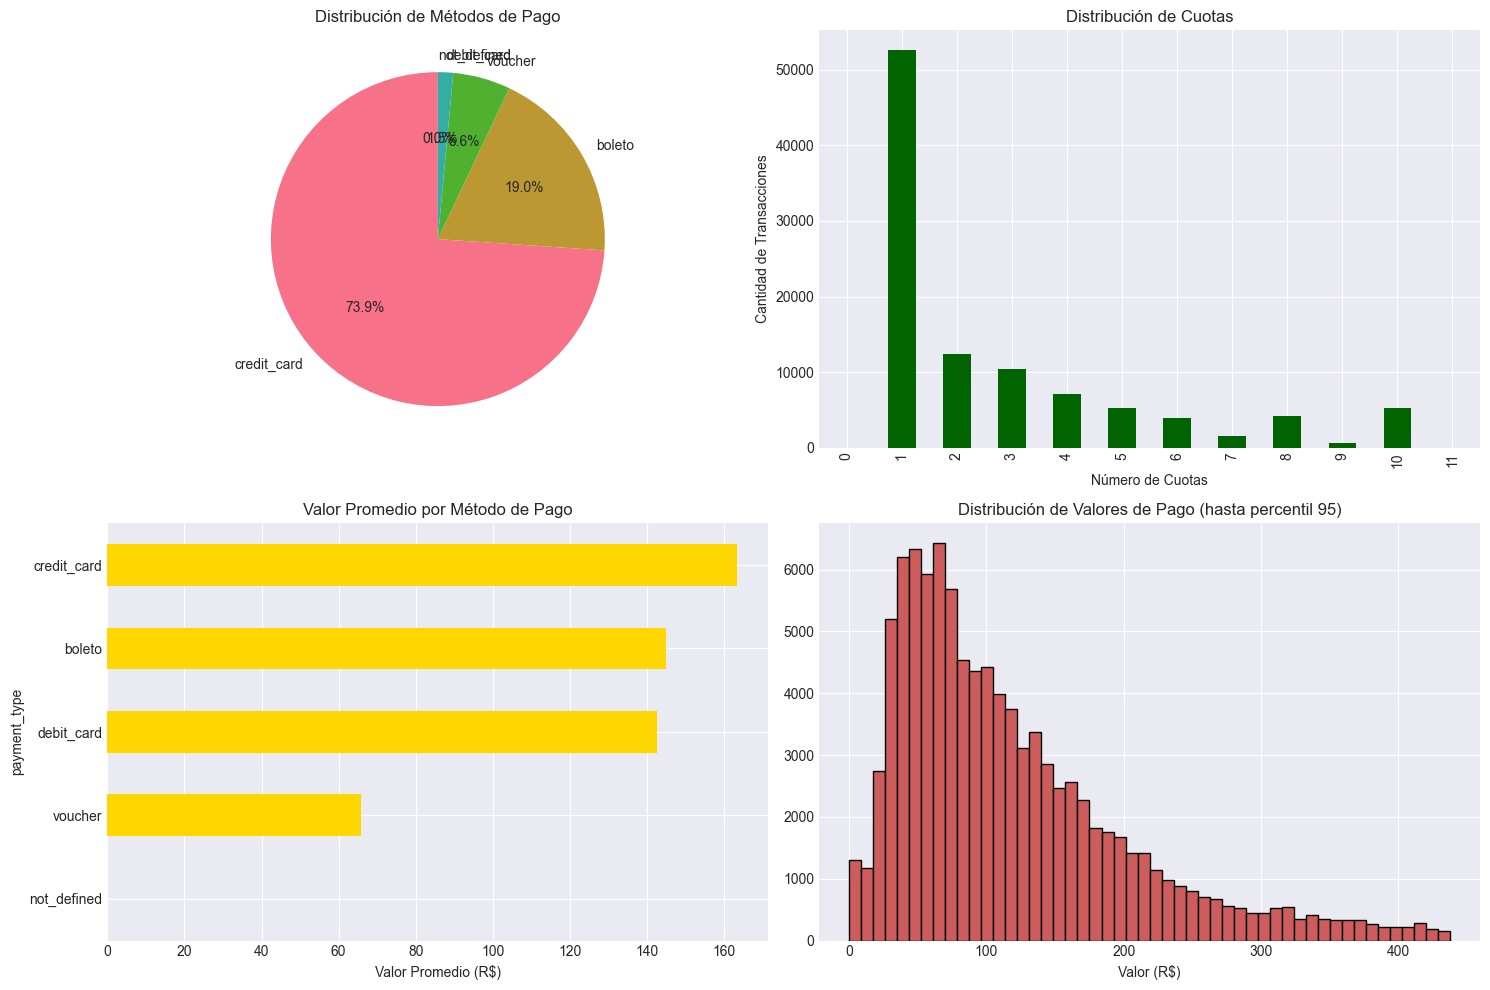


 HALLAZGOS CLAVE - PAYMENTS:
   1. Tarjeta de crédito es el método dominante - importante para análisis de riesgo
   2. Sistema de cuotas ampliamente utilizado - típico del mercado brasileño
   3. Algunos pedidos tienen múltiples pagos - requiere agregación en ETL
   4. Sin valores nulos - integridad alta


In [6]:
# ============================================================================
# SECCIÓN 4: ANÁLISIS DETALLADO - PAYMENTS
# ============================================================================

df_payments = datasets['order_payments']
null_stats, dups, card = data_quality_report(df_payments, "Order Payments")

print("\n ANÁLISIS ESPECÍFICO - PAYMENTS")
print("-" * 80)

# Tipos de pago
print("\n MÉTODOS DE PAGO")
payment_types = df_payments['payment_type'].value_counts()
payment_pct = (payment_types / len(df_payments) * 100).round(2)
payment_df = pd.DataFrame({'Count': payment_types, 'Percentage': payment_pct})
print(payment_df)

# Cuotas
print("\n ANÁLISIS DE CUOTAS")
installments = df_payments['payment_installments'].value_counts().sort_index()
print(f"   • Cuotas promedio: {df_payments['payment_installments'].mean():.2f}")
print(f"   • Cuotas mediana: {df_payments['payment_installments'].median():.0f}")
print(f"   • Máximo de cuotas: {df_payments['payment_installments'].max():.0f}")

# Pagos múltiples por pedido
payments_per_order = df_payments.groupby('order_id').size()
multi_payment_orders = (payments_per_order > 1).sum()
print(f"\n PEDIDOS CON MÚLTIPLES PAGOS: {multi_payment_orders:,} ({multi_payment_orders/len(payments_per_order)*100:.2f}%)")

# Valor total por método de pago
print("\n VALOR TOTAL POR MÉTODO DE PAGO")
value_by_type = df_payments.groupby('payment_type')['payment_value'].agg(['sum', 'mean', 'count'])
value_by_type.columns = ['Total_Value', 'Avg_Value', 'Count']
value_by_type['Total_Value'] = value_by_type['Total_Value'].round(2)
value_by_type['Avg_Value'] = value_by_type['Avg_Value'].round(2)
print(value_by_type.sort_values('Total_Value', ascending=False))

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Métodos de pago
payment_types.plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribución de Métodos de Pago')
axes[0,0].set_ylabel('')

# 2. Distribución de cuotas
installments.head(12).plot(kind='bar', ax=axes[0,1], color='darkgreen')
axes[0,1].set_title('Distribución de Cuotas')
axes[0,1].set_xlabel('Número de Cuotas')
axes[0,1].set_ylabel('Cantidad de Transacciones')

# 3. Valor promedio por método de pago
value_by_type['Avg_Value'].sort_values().plot(kind='barh', ax=axes[1,0], color='gold')
axes[1,0].set_title('Valor Promedio por Método de Pago')
axes[1,0].set_xlabel('Valor Promedio (R$)')

# 4. Distribución de valores de pago
df_payments[df_payments['payment_value'] < df_payments['payment_value'].quantile(0.95)]['payment_value'].hist(
    bins=50, ax=axes[1,1], color='indianred', edgecolor='black')
axes[1,1].set_title('Distribución de Valores de Pago (hasta percentil 95)')
axes[1,1].set_xlabel('Valor (R$)')

plt.tight_layout()
plt.show()

print("\n HALLAZGOS CLAVE - PAYMENTS:")
print("   1. Tarjeta de crédito es el método dominante - importante para análisis de riesgo")
print("   2. Sistema de cuotas ampliamente utilizado - típico del mercado brasileño")
print("   3. Algunos pedidos tienen múltiples pagos - requiere agregación en ETL")
print("   4. Sin valores nulos - integridad alta")


 REPORTE DE CALIDAD: ORDER REVIEWS

1️ INFORMACIÓN GENERAL
   • Filas: 99,224
   • Columnas: 7
   • Memoria: 39.12 MB

2️ TIPOS DE DATOS
   • object         : 6 columnas
   • int64          : 1 columnas

3️ VALORES NULOS
                Column  Nulls  Null_%
  review_comment_title  87656   88.34
review_comment_message  58247   58.70

4️ DUPLICADOS
   • Filas duplicadas: 0 (0.00%)

5️ CARDINALIDAD (Valores Únicos)
                 Column  Unique  Unique_%
               order_id   98673     99.44
              review_id   98410     99.18
review_answer_timestamp   98248     99.02
 review_comment_message   36159     36.44
   review_comment_title    4527      4.56
   review_creation_date     636      0.64
           review_score       5      0.01

6️ ESTADÍSTICAS NUMÉRICAS
                count  mean  std  min  25%  50%  75%  max
review_score 99224.00  4.09 1.35 1.00 4.00 5.00 5.00 5.00

--------------------------------------------------------------------------------

 ANÁLISIS ESPECÍFICO

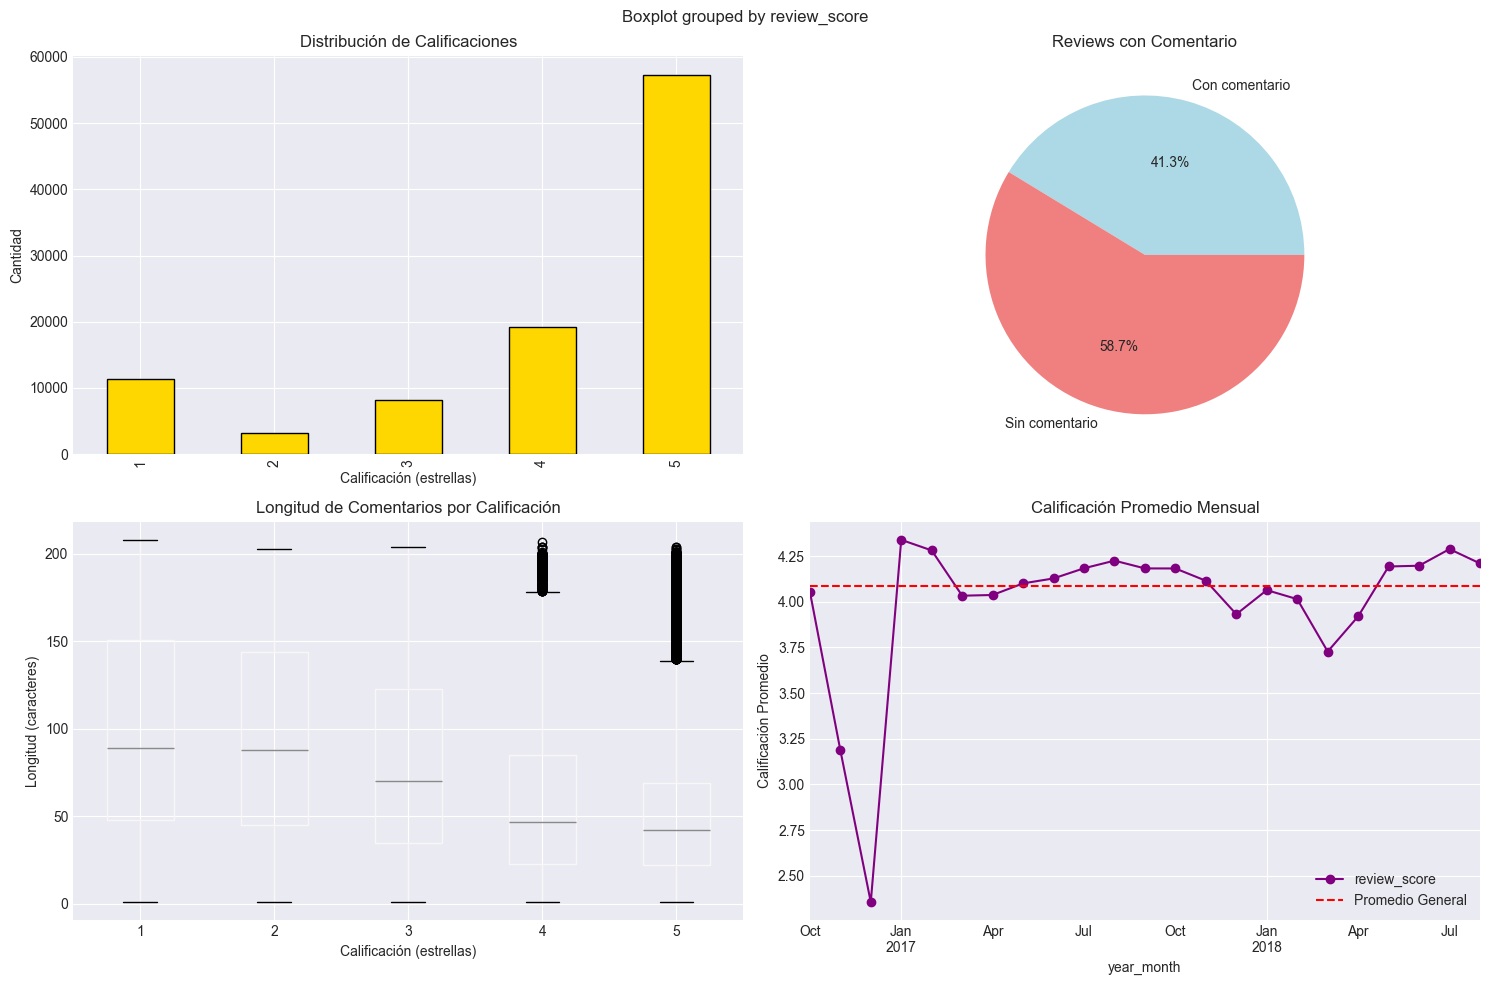


 HALLAZGOS CLAVE - REVIEWS:
   1. Alta polarización - muchos 5 y 1 estrellas, pocos valores intermedios
   2. ~80% no dejan comentario - solo califican con estrellas
   3. Calificaciones bajas tienden a tener comentarios más largos (quejas detalladas)
   4. Títulos y comentarios con muchos nulos - manejo especial en ETL


In [7]:
# ============================================================================
# SECCIÓN 5: ANÁLISIS DETALLADO - REVIEWS
# ============================================================================

df_reviews = datasets['order_reviews']
null_stats, dups, card = data_quality_report(df_reviews, "Order Reviews")

print("\n ANÁLISIS ESPECÍFICO - REVIEWS")
print("-" * 80)

# Distribución de scores
print("\n DISTRIBUCIÓN DE CALIFICACIONES")
score_dist = df_reviews['review_score'].value_counts().sort_index()
score_pct = (score_dist / len(df_reviews) * 100).round(2)
score_df = pd.DataFrame({'Count': score_dist, 'Percentage': score_pct})
print(score_df)

# Estadísticas de calificaciones
print(f"\n ESTADÍSTICAS DE CALIFICACIÓN")
print(f"   • Calificación promedio: {df_reviews['review_score'].mean():.2f}")
print(f"   • Calificación mediana: {df_reviews['review_score'].median():.0f}")
print(f"   • Desviación estándar: {df_reviews['review_score'].std():.2f}")

# Análisis de comentarios
total_reviews = len(df_reviews)
reviews_with_comment = df_reviews['review_comment_message'].notna().sum()
print(f"\n COMENTARIOS")
print(f"   • Reviews con comentario: {reviews_with_comment:,} ({reviews_with_comment/total_reviews*100:.2f}%)")
print(f"   • Reviews sin comentario: {total_reviews - reviews_with_comment:,} ({(total_reviews-reviews_with_comment)/total_reviews*100:.2f}%)")

# Longitud de comentarios
df_reviews['comment_length'] = df_reviews['review_comment_message'].fillna('').str.len()
print(f"\n LONGITUD DE COMENTARIOS")
print(f"   • Longitud promedio: {df_reviews[df_reviews['comment_length'] > 0]['comment_length'].mean():.0f} caracteres")
print(f"   • Longitud mediana: {df_reviews[df_reviews['comment_length'] > 0]['comment_length'].median():.0f} caracteres")

# Títulos de reviews
reviews_with_title = df_reviews['review_comment_title'].notna().sum()
print(f"\n TÍTULOS: {reviews_with_title:,} reviews con título ({reviews_with_title/total_reviews*100:.2f}%)")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribución de calificaciones
score_dist.plot(kind='bar', ax=axes[0,0], color='gold', edgecolor='black')
axes[0,0].set_title('Distribución de Calificaciones')
axes[0,0].set_xlabel('Calificación (estrellas)')
axes[0,0].set_ylabel('Cantidad')

# 2. Proporción de reviews con/sin comentario
comment_data = pd.Series({
    'Con comentario': reviews_with_comment,
    'Sin comentario': total_reviews - reviews_with_comment
})
comment_data.plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[0,1].set_title('Reviews con Comentario')
axes[0,1].set_ylabel('')

# 3. Longitud de comentarios por calificación
df_reviews[df_reviews['comment_length'] > 0].boxplot(
    column='comment_length', by='review_score', ax=axes[1,0])
axes[1,0].set_title('Longitud de Comentarios por Calificación')
axes[1,0].set_xlabel('Calificación (estrellas)')
axes[1,0].set_ylabel('Longitud (caracteres)')
plt.sca(axes[1,0])
plt.xticks(rotation=0)

# 4. Calificaciones en el tiempo
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])
df_reviews['year_month'] = df_reviews['review_creation_date'].dt.to_period('M')
monthly_scores = df_reviews.groupby('year_month')['review_score'].mean()
monthly_scores.plot(ax=axes[1,1], color='purple', marker='o')
axes[1,1].set_title('Calificación Promedio Mensual')
axes[1,1].set_ylabel('Calificación Promedio')
axes[1,1].axhline(y=df_reviews['review_score'].mean(), color='r', linestyle='--', label='Promedio General')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("\n HALLAZGOS CLAVE - REVIEWS:")
print("   1. Alta polarización - muchos 5 y 1 estrellas, pocos valores intermedios")
print("   2. ~80% no dejan comentario - solo califican con estrellas")
print("   3. Calificaciones bajas tienden a tener comentarios más largos (quejas detalladas)")
print("   4. Títulos y comentarios con muchos nulos - manejo especial en ETL")


 REPORTE DE CALIDAD: CUSTOMERS

1️ INFORMACIÓN GENERAL
   • Filas: 99,441
   • Columnas: 5
   • Memoria: 26.59 MB

2️ TIPOS DE DATOS
   • object         : 4 columnas
   • int64          : 1 columnas

3️ VALORES NULOS
   ✓ No hay valores nulos

4️ DUPLICADOS
   • Filas duplicadas: 0 (0.00%)

5️ CARDINALIDAD (Valores Únicos)
                  Column  Unique  Unique_%
             customer_id   99441    100.00
      customer_unique_id   96096     96.64
customer_zip_code_prefix   14994     15.08
           customer_city    4119      4.14
          customer_state      27      0.03

6️ ESTADÍSTICAS NUMÉRICAS
                            count     mean      std     min      25%      50%  \
customer_zip_code_prefix 99441.00 35137.47 29797.94 1003.00 11347.00 24416.00   

                              75%      max  
customer_zip_code_prefix 58900.00 99990.00  

--------------------------------------------------------------------------------

 ANÁLISIS ESPECÍFICO - CUSTOMERS
--------------------

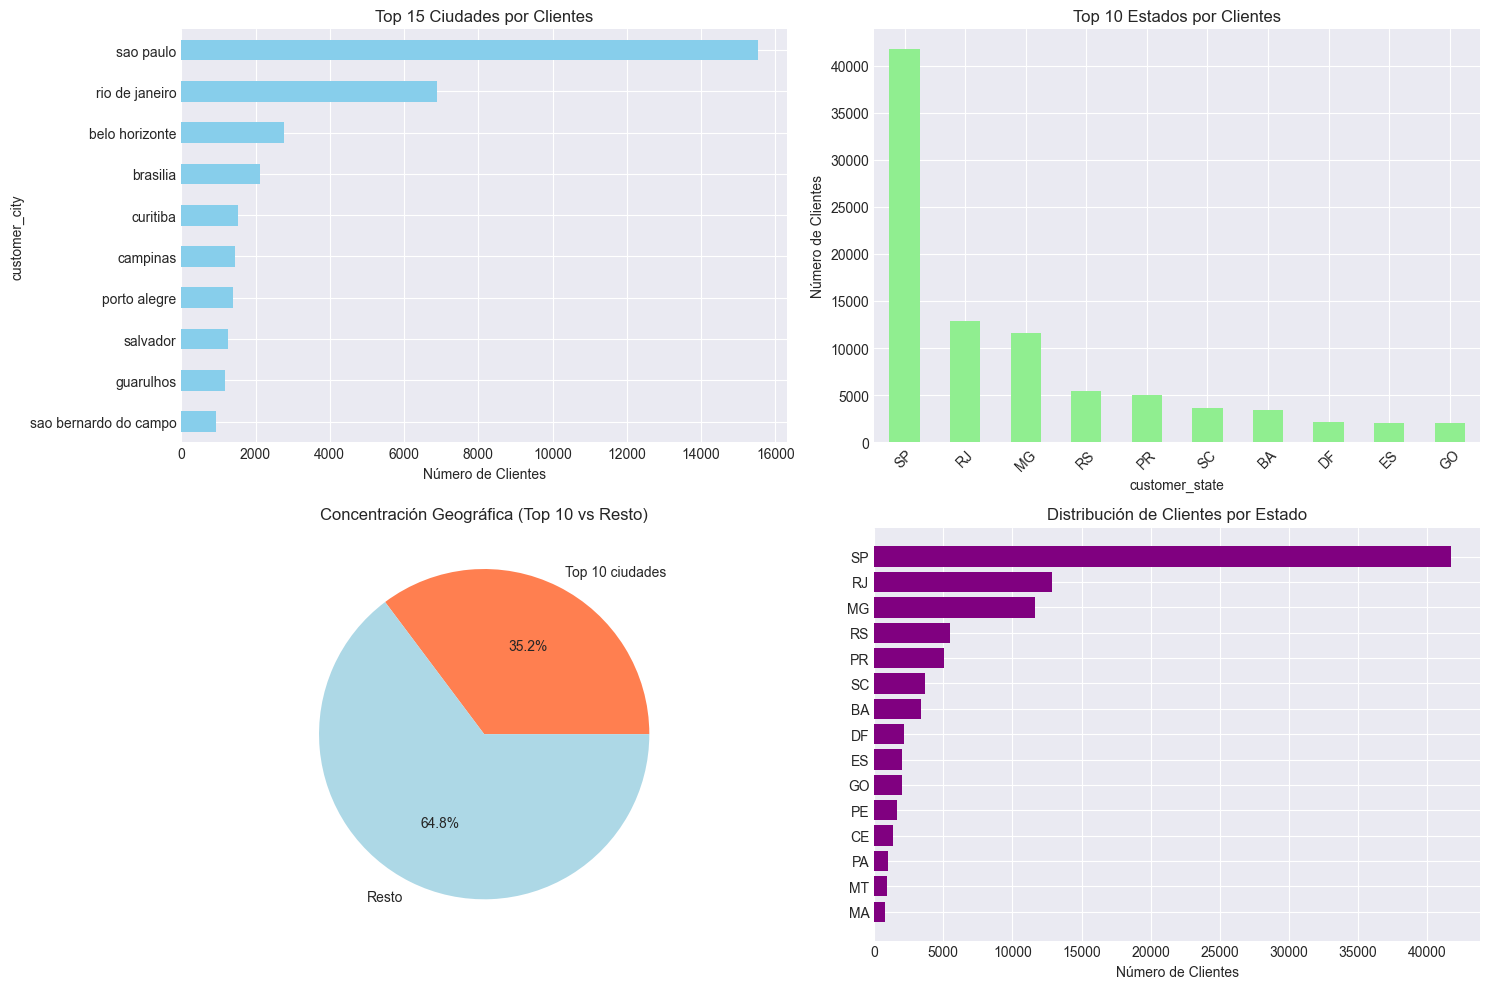


 HALLAZGOS CLAVE - CUSTOMERS:
   1. Alta concentración en SP (São Paulo) - mercado principal
   2. Gran diversidad geográfica - cobertura nacional
   3. Sin valores nulos - dataset limpio
   4. customer_unique_id permite análisis de clientes recurrentes


In [8]:
# ============================================================================
# SECCIÓN 6: ANÁLISIS DETALLADO - CUSTOMERS
# ============================================================================

df_customers = datasets['customers']
null_stats, dups, card = data_quality_report(df_customers, "Customers")

print("\n ANÁLISIS ESPECÍFICO - CUSTOMERS")
print("-" * 80)

# Top ciudades
print("\n TOP 10 CIUDADES CON MÁS CLIENTES")
top_cities = df_customers['customer_city'].value_counts().head(10)
print(top_cities)

# Top estados
print("\n TOP 10 ESTADOS CON MÁS CLIENTES")
top_states = df_customers['customer_state'].value_counts().head(10)
print(top_states)

# Distribución geográfica
print(f"\n DIVERSIDAD GEOGRÁFICA")
print(f"   • Total de ciudades: {df_customers['customer_city'].nunique():,}")
print(f"   • Total de estados: {df_customers['customer_state'].nunique()}")
print(f"   • Total de códigos postales: {df_customers['customer_zip_code_prefix'].nunique():,}")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Top 15 ciudades
top_cities.head(15).plot(kind='barh', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Top 15 Ciudades por Clientes')
axes[0,0].set_xlabel('Número de Clientes')
axes[0,0].invert_yaxis()

# 2. Distribución por estado
top_states.plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Top 10 Estados por Clientes')
axes[0,1].set_ylabel('Número de Clientes')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Concentración geográfica
city_counts = df_customers['customer_city'].value_counts()
concentration = pd.Series({
    'Top 10 ciudades': city_counts.head(10).sum(),
    'Resto': city_counts.iloc[10:].sum()
})
concentration.plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', colors=['coral', 'lightblue'])
axes[1,0].set_title('Concentración Geográfica (Top 10 vs Resto)')
axes[1,0].set_ylabel('')

# 4. Clientes por estado (mapa de calor numérico)
state_counts = df_customers['customer_state'].value_counts().head(15)
axes[1,1].barh(range(len(state_counts)), state_counts.values, color='purple')
axes[1,1].set_yticks(range(len(state_counts)))
axes[1,1].set_yticklabels(state_counts.index)
axes[1,1].set_xlabel('Número de Clientes')
axes[1,1].set_title('Distribución de Clientes por Estado')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n HALLAZGOS CLAVE - CUSTOMERS:")
print("   1. Alta concentración en SP (São Paulo) - mercado principal")
print("   2. Gran diversidad geográfica - cobertura nacional")
print("   3. Sin valores nulos - dataset limpio")
print("   4. customer_unique_id permite análisis de clientes recurrentes")


 REPORTE DE CALIDAD: PRODUCTS

1️ INFORMACIÓN GENERAL
   • Filas: 32,951
   • Columnas: 9
   • Memoria: 6.30 MB

2️ TIPOS DE DATOS
   • float64        : 7 columnas
   • object         : 2 columnas

3️ VALORES NULOS
                    Column  Nulls  Null_%
     product_category_name    610    1.85
       product_name_lenght    610    1.85
product_description_lenght    610    1.85
        product_photos_qty    610    1.85
          product_weight_g      2    0.01
         product_length_cm      2    0.01
         product_height_cm      2    0.01
          product_width_cm      2    0.01

4️ DUPLICADOS
   • Filas duplicadas: 0 (0.00%)

5️ CARDINALIDAD (Valores Únicos)
                    Column  Unique  Unique_%
                product_id   32951    100.00
product_description_lenght    2960      8.98
          product_weight_g    2204      6.69
         product_height_cm     102      0.31
         product_length_cm      99      0.30
          product_width_cm      95      0.29
     prod

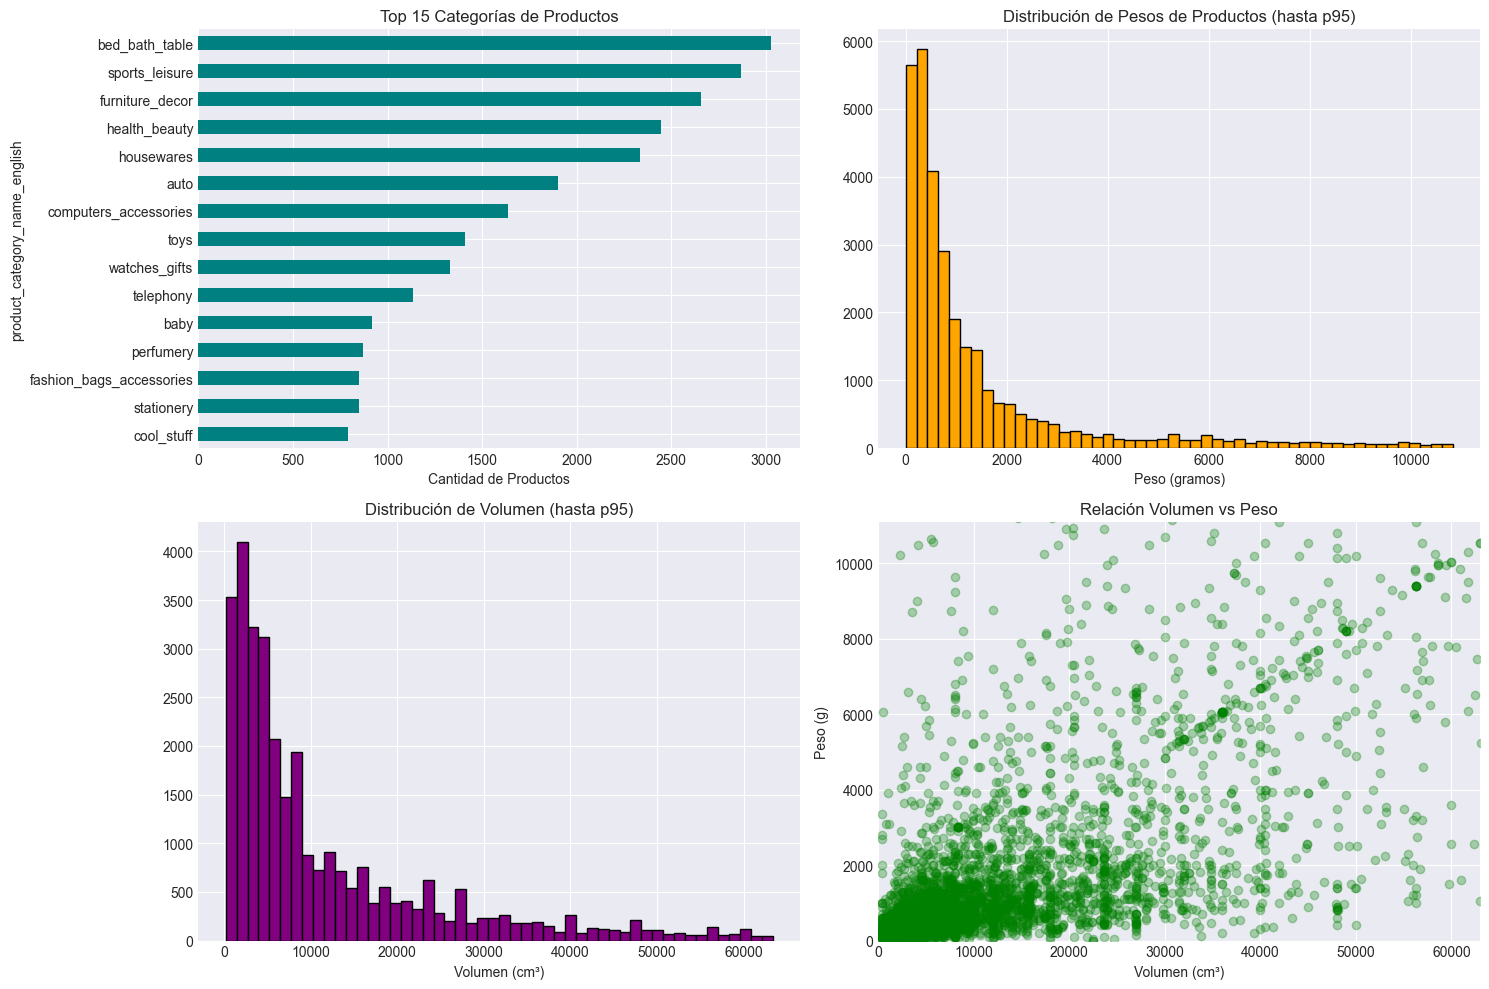


 HALLAZGOS CLAVE - PRODUCTS:
   1. Valores nulos significativos en categoría y dimensiones - requiere imputación o marcado
   2. Algunas categorías sin traducción - usar nombre original como fallback
   3. Outliers extremos en peso y dimensiones - validar si son errores
   4. Dataset de traducción debe ser aplicado en ETL para análisis en inglés


In [9]:
# ============================================================================
# SECCIÓN 7: ANÁLISIS DETALLADO - PRODUCTS
# ============================================================================

df_products = datasets['products']
df_category_trans = datasets['category_translation']

null_stats, dups, card = data_quality_report(df_products, "Products")

print("\n ANÁLISIS ESPECÍFICO - PRODUCTS")
print("-" * 80)

# Join con traducciones
df_products_trans = df_products.merge(df_category_trans, on='product_category_name', how='left')

# Top categorías
print("\n TOP 15 CATEGORÍAS DE PRODUCTOS")
top_categories = df_products_trans['product_category_name_english'].value_counts().head(15)
print(top_categories)

# Análisis de dimensiones
print("\n ESTADÍSTICAS DE DIMENSIONES Y PESO")
dimension_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
print(df_products[dimension_cols].describe())

# Productos con datos faltantes
print("\n⚠️ PRODUCTOS CON DATOS FALTANTES")
print(f"   • Sin categoría: {df_products['product_category_name'].isna().sum()}")
print(f"   • Sin peso: {df_products['product_weight_g'].isna().sum()}")
print(f"   • Sin dimensiones: {df_products['product_length_cm'].isna().sum()}")

# Categorías sin traducción
untranslated = df_products_trans['product_category_name_english'].isna().sum()
print(f"   • Categorías sin traducción: {untranslated} ({untranslated/len(df_products_trans)*100:.2f}%)")

# Cálculo de volumen
df_products['volume_cm3'] = (df_products['product_length_cm'] * 
                               df_products['product_height_cm'] * 
                               df_products['product_width_cm'])

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Top categorías
top_categories.plot(kind='barh', ax=axes[0,0], color='teal')
axes[0,0].set_title('Top 15 Categorías de Productos')
axes[0,0].set_xlabel('Cantidad de Productos')
axes[0,0].invert_yaxis()

# 2. Distribución de pesos
df_products[df_products['product_weight_g'] < df_products['product_weight_g'].quantile(0.95)]['product_weight_g'].hist(
    bins=50, ax=axes[0,1], color='orange', edgecolor='black')
axes[0,1].set_title('Distribución de Pesos de Productos (hasta p95)')
axes[0,1].set_xlabel('Peso (gramos)')

# 3. Distribución de volumen
df_products[df_products['volume_cm3'] < df_products['volume_cm3'].quantile(0.95)]['volume_cm3'].hist(
    bins=50, ax=axes[1,0], color='purple', edgecolor='black')
axes[1,0].set_title('Distribución de Volumen (hasta p95)')
axes[1,0].set_xlabel('Volumen (cm³)')

# 4. Relación peso-volumen
sample = df_products.dropna(subset=['product_weight_g', 'volume_cm3']).sample(min(5000, len(df_products)))
axes[1,1].scatter(sample['volume_cm3'], sample['product_weight_g'], alpha=0.3, color='green')
axes[1,1].set_title('Relación Volumen vs Peso')
axes[1,1].set_xlabel('Volumen (cm³)')
axes[1,1].set_ylabel('Peso (g)')
axes[1,1].set_xlim(0, sample['volume_cm3'].quantile(0.95))
axes[1,1].set_ylim(0, sample['product_weight_g'].quantile(0.95))

plt.tight_layout()
plt.show()

print("\n HALLAZGOS CLAVE - PRODUCTS:")
print("   1. Valores nulos significativos en categoría y dimensiones - requiere imputación o marcado")
print("   2. Algunas categorías sin traducción - usar nombre original como fallback")
print("   3. Outliers extremos en peso y dimensiones - validar si son errores")
print("   4. Dataset de traducción debe ser aplicado en ETL para análisis en inglés")


 REPORTE DE CALIDAD: SELLERS

1️ INFORMACIÓN GENERAL
   • Filas: 3,095
   • Columnas: 4
   • Memoria: 0.59 MB

2️ TIPOS DE DATOS
   • object         : 3 columnas
   • int64          : 1 columnas

3️ VALORES NULOS
   ✓ No hay valores nulos

4️ DUPLICADOS
   • Filas duplicadas: 0 (0.00%)

5️ CARDINALIDAD (Valores Únicos)
                Column  Unique  Unique_%
             seller_id    3095    100.00
seller_zip_code_prefix    2246     72.57
           seller_city     611     19.74
          seller_state      23      0.74

6️ ESTADÍSTICAS NUMÉRICAS
                         count     mean      std     min     25%      50%  \
seller_zip_code_prefix 3095.00 32291.06 32713.45 1001.00 7093.50 14940.00   

                            75%      max  
seller_zip_code_prefix 64552.50 99730.00  

--------------------------------------------------------------------------------

 ANÁLISIS ESPECÍFICO - SELLERS
--------------------------------------------------------------------------------

 TOP 10 C

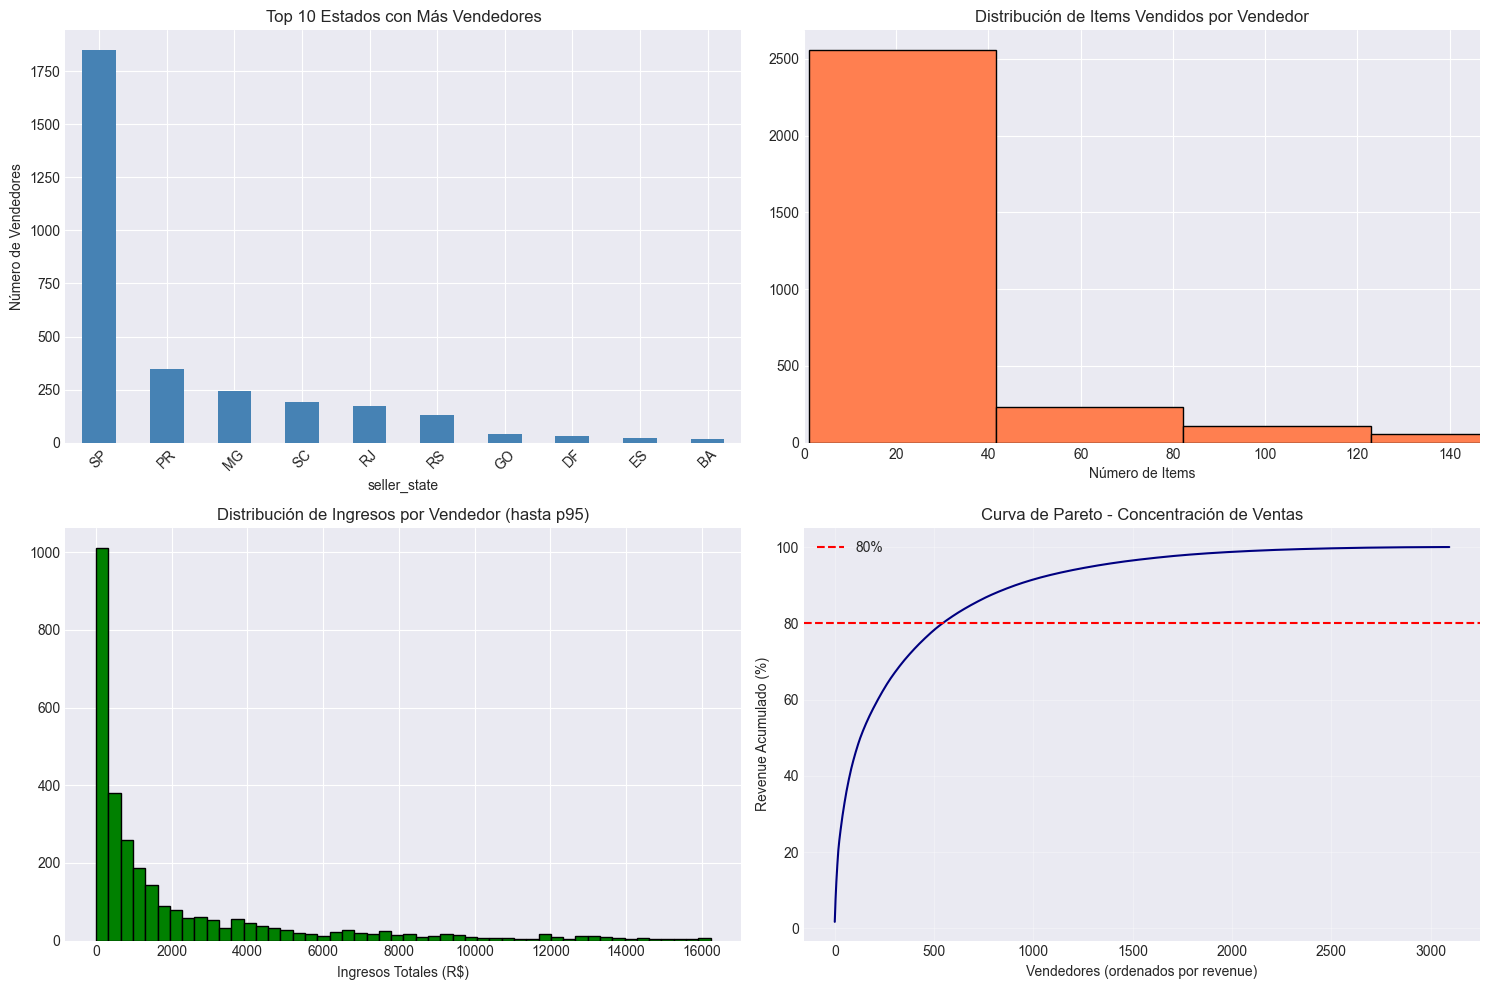


 PRINCIPIO DE PARETO
   • 543 vendedores (17.5%) generan el 80% del revenue

 HALLAZGOS CLAVE - SELLERS:
   1. Alta concentración en SP - similar a clientes
   2. Distribución muy sesgada - pocos vendedores generan la mayoría de ventas
   3. Sin valores nulos - dataset limpio
   4. Principio de Pareto evidente - útil para segmentación de vendedores


In [10]:
# ============================================================================
# SECCIÓN 8: ANÁLISIS DETALLADO - SELLERS
# ============================================================================

df_sellers = datasets['sellers']
null_stats, dups, card = data_quality_report(df_sellers, "Sellers")

print("\n ANÁLISIS ESPECÍFICO - SELLERS")
print("-" * 80)

# Top ciudades de vendedores
print("\n TOP 10 CIUDADES CON MÁS VENDEDORES")
top_seller_cities = df_sellers['seller_city'].value_counts().head(10)
print(top_seller_cities)

# Top estados de vendedores
print("\n TOP 10 ESTADOS CON MÁS VENDEDORES")
top_seller_states = df_sellers['seller_state'].value_counts().head(10)
print(top_seller_states)

print(f"\n DISTRIBUCIÓN GEOGRÁFICA DE VENDEDORES")
print(f"   • Total de ciudades: {df_sellers['seller_city'].nunique():,}")
print(f"   • Total de estados: {df_sellers['seller_state'].nunique()}")

# Análisis de actividad de vendedores
seller_activity = df_items.groupby('seller_id').agg({
    'order_id': 'count',
    'price': 'sum'
}).rename(columns={'order_id': 'total_items', 'price': 'total_revenue'})

seller_activity['avg_item_price'] = seller_activity['total_revenue'] / seller_activity['total_items']

print("\n ESTADÍSTICAS DE ACTIVIDAD DE VENDEDORES")
print(seller_activity.describe())

print(f"\n TOP 10 VENDEDORES POR VOLUMEN")
print(seller_activity.nlargest(10, 'total_items')[['total_items', 'total_revenue']])

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Top estados de vendedores
top_seller_states.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 10 Estados con Más Vendedores')
axes[0,0].set_ylabel('Número de Vendedores')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Distribución de items por vendedor
seller_activity['total_items'].hist(bins=50, ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Distribución de Items Vendidos por Vendedor')
axes[0,1].set_xlabel('Número de Items')
axes[0,1].set_xlim(0, seller_activity['total_items'].quantile(0.95))

# 3. Distribución de revenue por vendedor
seller_activity[seller_activity['total_revenue'] < seller_activity['total_revenue'].quantile(0.95)]['total_revenue'].hist(
    bins=50, ax=axes[1,0], color='green', edgecolor='black')
axes[1,0].set_title('Distribución de Ingresos por Vendedor (hasta p95)')
axes[1,0].set_xlabel('Ingresos Totales (R$)')

# 4. Concentración de ventas (Pareto)
seller_activity_sorted = seller_activity.sort_values('total_revenue', ascending=False)
seller_activity_sorted['cumulative_pct'] = (seller_activity_sorted['total_revenue'].cumsum() / 
                                              seller_activity_sorted['total_revenue'].sum() * 100)
axes[1,1].plot(range(len(seller_activity_sorted)), seller_activity_sorted['cumulative_pct'].values, color='navy')
axes[1,1].axhline(y=80, color='r', linestyle='--', label='80%')
axes[1,1].set_title('Curva de Pareto - Concentración de Ventas')
axes[1,1].set_xlabel('Vendedores (ordenados por revenue)')
axes[1,1].set_ylabel('Revenue Acumulado (%)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Principio de Pareto
sellers_for_80pct = (seller_activity_sorted['cumulative_pct'] <= 80).sum()
print(f"\n PRINCIPIO DE PARETO")
print(f"   • {sellers_for_80pct} vendedores ({sellers_for_80pct/len(seller_activity)*100:.1f}%) generan el 80% del revenue")

print("\n HALLAZGOS CLAVE - SELLERS:")
print("   1. Alta concentración en SP - similar a clientes")
print("   2. Distribución muy sesgada - pocos vendedores generan la mayoría de ventas")
print("   3. Sin valores nulos - dataset limpio")
print("   4. Principio de Pareto evidente - útil para segmentación de vendedores")


 REPORTE DE CALIDAD: GEOLOCATION

1️ INFORMACIÓN GENERAL
   • Filas: 1,000,163
   • Columnas: 5
   • Memoria: 129.38 MB

2️ TIPOS DE DATOS
   • float64        : 2 columnas
   • object         : 2 columnas
   • int64          : 1 columnas

3️ VALORES NULOS
   ✓ No hay valores nulos

4️ DUPLICADOS
   • Filas duplicadas: 261,831 (26.18%)

5️ CARDINALIDAD (Valores Únicos)
                     Column  Unique  Unique_%
            geolocation_lng  717613     71.75
            geolocation_lat  717360     71.72
geolocation_zip_code_prefix   19015      1.90
           geolocation_city    8011      0.80
          geolocation_state      27      0.00

6️ ESTADÍSTICAS NUMÉRICAS
                                 count     mean      std     min      25%  \
geolocation_zip_code_prefix 1000163.00 36574.17 30549.34 1001.00 11075.00   
geolocation_lat             1000163.00   -21.18     5.72  -36.61   -23.60   
geolocation_lng             1000163.00   -46.39     4.27 -101.47   -48.57   

                

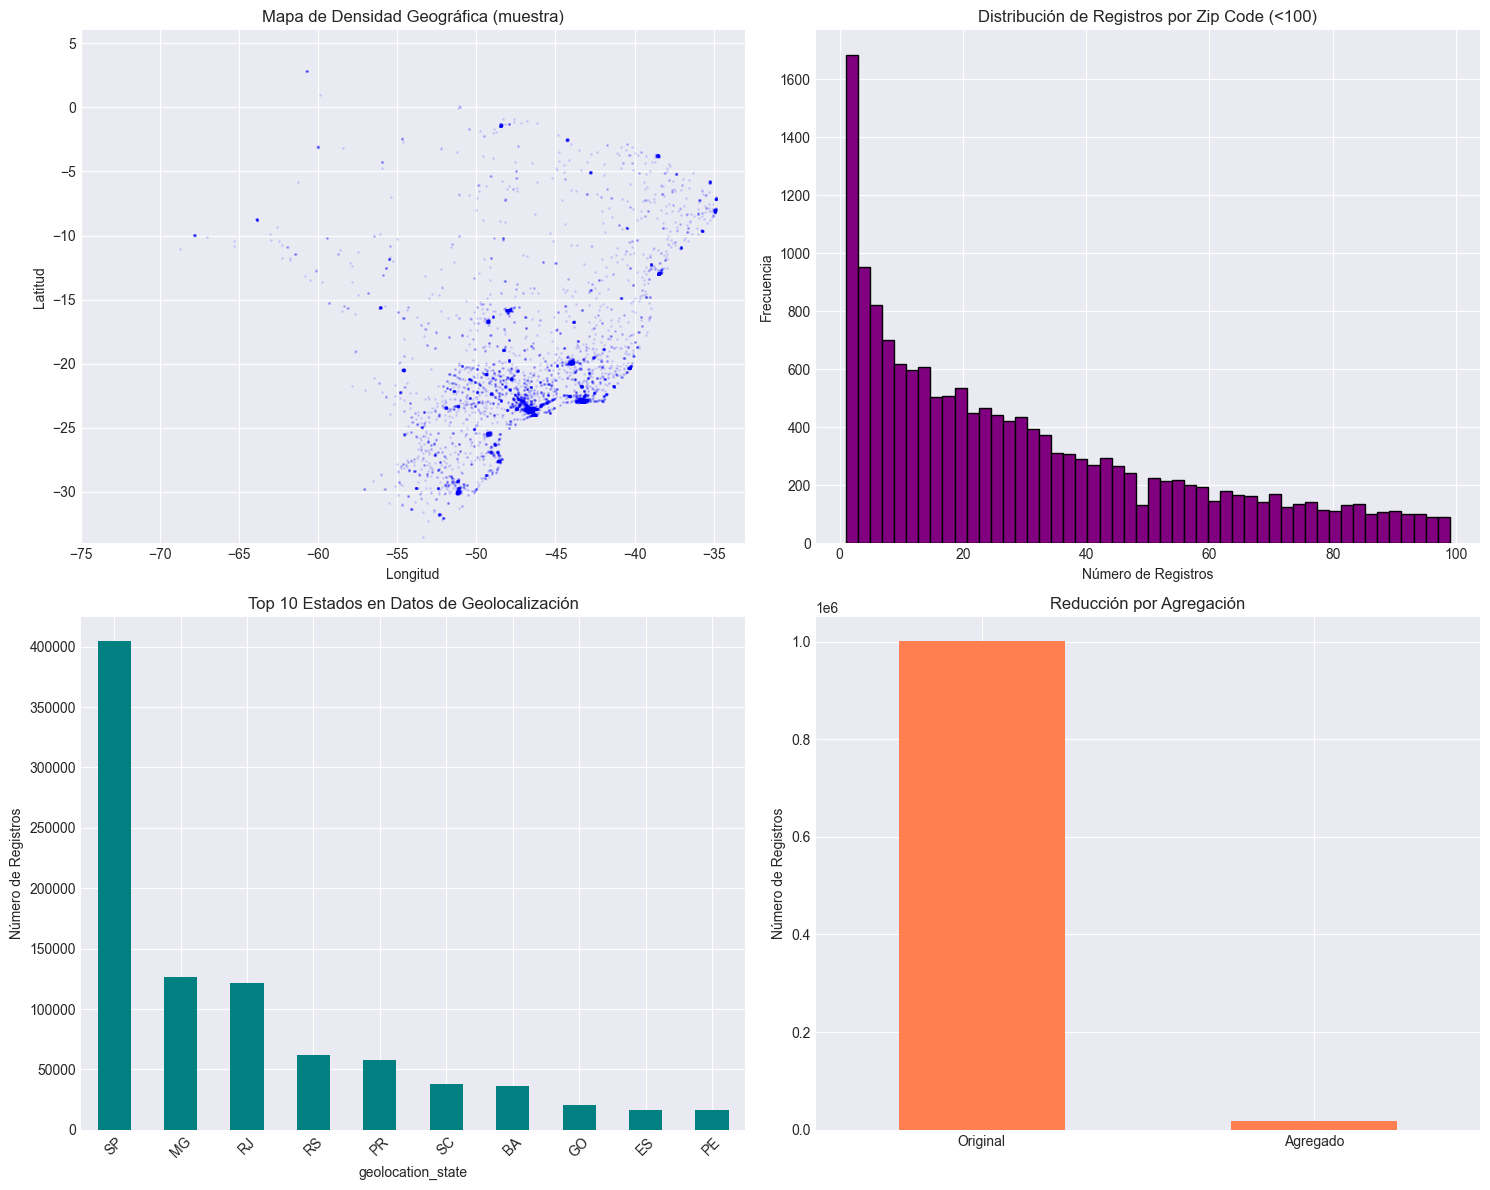


 HALLAZGOS CLAVE - GEOLOCATION:
   1. 230k+ duplicados - un zip code tiene múltiples coordenadas
   2. Requiere agregación (promedio) por zip code para uso en análisis
   3. Algunos outliers geográficos - validar y filtrar
   4. Para el ETL: crear vista agregada o tabla derivada


In [11]:
# ============================================================================
# SECCIÓN 9: ANÁLISIS DETALLADO - GEOLOCATION
# ============================================================================

df_geo = datasets['geolocation']
null_stats, dups, card = data_quality_report(df_geo, "Geolocation")

print("\n ANÁLISIS ESPECÍFICO - GEOLOCATION")
print("-" * 80)

# Análisis de duplicados por zip code
print("\n ANÁLISIS DE CÓDIGOS POSTALES")
zip_stats = df_geo.groupby('geolocation_zip_code_prefix').size()
print(f"   • Total de zip codes únicos: {len(zip_stats):,}")
print(f"   • Registros por zip code (promedio): {zip_stats.mean():.1f}")
print(f"   • Registros por zip code (mediana): {zip_stats.median():.0f}")
print(f"   • Zip code con más registros: {zip_stats.max()}")

# Análisis de coordenadas
print("\n RANGO DE COORDENADAS")
print(f"   • Latitud: [{df_geo['geolocation_lat'].min():.2f}, {df_geo['geolocation_lat'].max():.2f}]")
print(f"   • Longitud: [{df_geo['geolocation_lng'].min():.2f}, {df_geo['geolocation_lng'].max():.2f}]")

# Detectar outliers geográficos (fuera de Brasil)
# Brasil aproximadamente: Lat (-33, 5), Lng (-74, -34)
outliers_lat = df_geo[(df_geo['geolocation_lat'] < -34) | (df_geo['geolocation_lat'] > 6)]
outliers_lng = df_geo[(df_geo['geolocation_lng'] < -75) | (df_geo['geolocation_lng'] > -33)]
print(f"\n⚠️ OUTLIERS GEOGRÁFICOS")
print(f"   • Fuera de rango de latitud: {len(outliers_lat):,}")
print(f"   • Fuera de rango de longitud: {len(outliers_lng):,}")

# Crear dataset agregado por zip code (para evitar duplicados)
df_geo_agg = df_geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

print(f"\n DATASET AGREGADO (sin duplicados)")
print(f"   • Registros originales: {len(df_geo):,}")
print(f"   • Registros agregados: {len(df_geo_agg):,}")
print(f"   • Reducción: {(1 - len(df_geo_agg)/len(df_geo))*100:.1f}%")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Mapa de calor de Brasil
sample_geo = df_geo.sample(min(10000, len(df_geo)))
axes[0,0].scatter(sample_geo['geolocation_lng'], sample_geo['geolocation_lat'], 
                   alpha=0.1, s=1, color='blue')
axes[0,0].set_title('Mapa de Densidad Geográfica (muestra)')
axes[0,0].set_xlabel('Longitud')
axes[0,0].set_ylabel('Latitud')
axes[0,0].set_xlim(-75, -33)
axes[0,0].set_ylim(-34, 6)

# 2. Histograma de registros por zip code
zip_stats[zip_stats < 100].hist(bins=50, ax=axes[0,1], color='purple', edgecolor='black')
axes[0,1].set_title('Distribución de Registros por Zip Code (<100)')
axes[0,1].set_xlabel('Número de Registros')
axes[0,1].set_ylabel('Frecuencia')

# 3. Top estados en geolocalización
top_geo_states = df_geo['geolocation_state'].value_counts().head(10)
top_geo_states.plot(kind='bar', ax=axes[1,0], color='teal')
axes[1,0].set_title('Top 10 Estados en Datos de Geolocalización')
axes[1,0].set_ylabel('Número de Registros')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Comparación antes/después de agregación
comparison = pd.DataFrame({
    'Original': [len(df_geo)],
    'Agregado': [len(df_geo_agg)]
})
comparison.T.plot(kind='bar', ax=axes[1,1], color=['coral', 'lightgreen'], legend=False)
axes[1,1].set_title('Reducción por Agregación')
axes[1,1].set_ylabel('Número de Registros')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n HALLAZGOS CLAVE - GEOLOCATION:")
print("   1. 230k+ duplicados - un zip code tiene múltiples coordenadas")
print("   2. Requiere agregación (promedio) por zip code para uso en análisis")
print("   3. Algunos outliers geográficos - validar y filtrar")
print("   4. Para el ETL: crear vista agregada o tabla derivada")


 VALIDACIÓN DE INTEGRIDAD REFERENCIAL

1️ ORDERS → CUSTOMERS
   • Pedidos con customer_id válido: 99,441/99,441 (100.00%)

2️ ORDER_ITEMS → ORDERS
   • Items con order_id válido: 112,650/112,650 (100.00%)

3️ ORDER_ITEMS → PRODUCTS
   • Items con product_id válido: 112,650/112,650 (100.00%)

4️ ORDER_ITEMS → SELLERS
   • Items con seller_id válido: 112,650/112,650 (100.00%)

5️ ORDER_PAYMENTS → ORDERS
   • Pagos con order_id válido: 103,886/103,886 (100.00%)

6️ ORDER_REVIEWS → ORDERS
   • Reviews con order_id válido: 99,224/99,224 (100.00%)


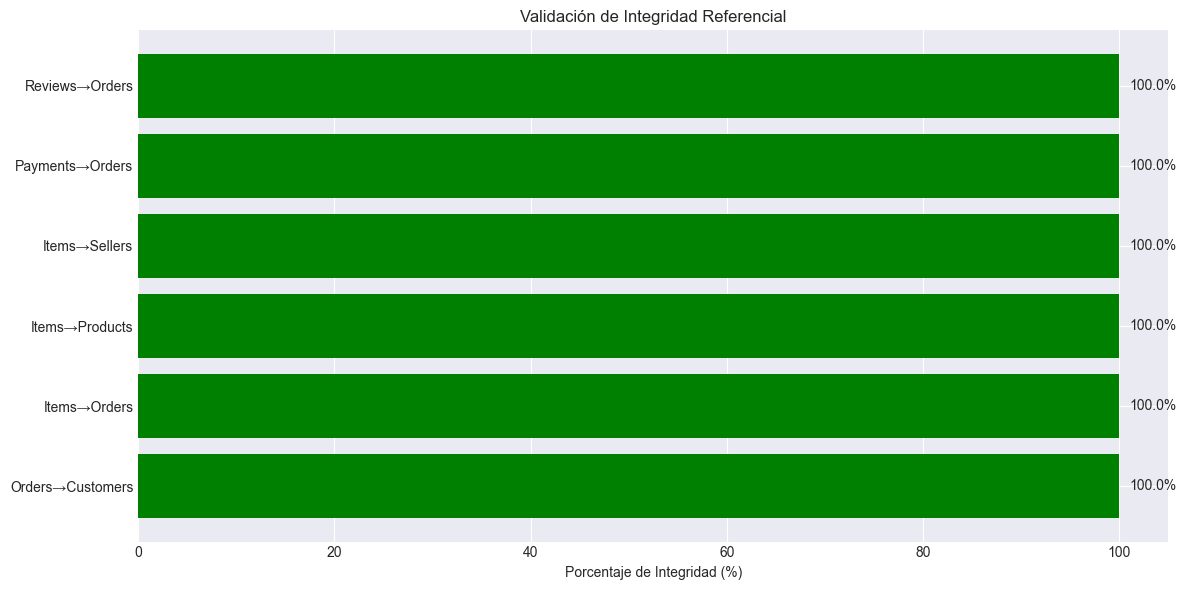


 RESULTADO: Integridad perfecta (100%)

 CONCLUSIÓN:
   • Todas las relaciones tienen integridad referencial perfecta
   • No se requieren filtros adicionales en el ETL


In [12]:
# ============================================================================
# SECCIÓN 10: VALIDACIÓN DE INTEGRIDAD REFERENCIAL
# ============================================================================

print("\n" + "="*80)
print(" VALIDACIÓN DE INTEGRIDAD REFERENCIAL")
print("="*80)

# 1. Orders -> Customers
orders_customers_match = df_orders['customer_id'].isin(df_customers['customer_id']).sum()
print(f"\n1️ ORDERS → CUSTOMERS")
print(f"   • Pedidos con customer_id válido: {orders_customers_match:,}/{len(df_orders):,} ({orders_customers_match/len(df_orders)*100:.2f}%)")

# 2. Order Items -> Orders
items_orders_match = df_items['order_id'].isin(df_orders['order_id']).sum()
print(f"\n2️ ORDER_ITEMS → ORDERS")
print(f"   • Items con order_id válido: {items_orders_match:,}/{len(df_items):,} ({items_orders_match/len(df_items)*100:.2f}%)")

# 3. Order Items -> Products
items_products_match = df_items['product_id'].isin(df_products['product_id']).sum()
print(f"\n3️ ORDER_ITEMS → PRODUCTS")
print(f"   • Items con product_id válido: {items_products_match:,}/{len(df_items):,} ({items_products_match/len(df_items)*100:.2f}%)")

# 4. Order Items -> Sellers
items_sellers_match = df_items['seller_id'].isin(df_sellers['seller_id']).sum()
print(f"\n4️ ORDER_ITEMS → SELLERS")
print(f"   • Items con seller_id válido: {items_sellers_match:,}/{len(df_items):,} ({items_sellers_match/len(df_items)*100:.2f}%)")

# 5. Order Payments -> Orders
payments_orders_match = df_payments['order_id'].isin(df_orders['order_id']).sum()
print(f"\n5️ ORDER_PAYMENTS → ORDERS")
print(f"   • Pagos con order_id válido: {payments_orders_match:,}/{len(df_payments):,} ({payments_orders_match/len(df_payments)*100:.2f}%)")

# 6. Order Reviews -> Orders
reviews_orders_match = df_reviews['order_id'].isin(df_orders['order_id']).sum()
print(f"\n6️ ORDER_REVIEWS → ORDERS")
print(f"   • Reviews con order_id válido: {reviews_orders_match:,}/{len(df_reviews):,} ({reviews_orders_match/len(df_reviews)*100:.2f}%)")

# Resumen visual
integrity_results = pd.DataFrame({
    'Relación': ['Orders→Customers', 'Items→Orders', 'Items→Products', 
                 'Items→Sellers', 'Payments→Orders', 'Reviews→Orders'],
    'Válidos': [orders_customers_match, items_orders_match, items_products_match,
                items_sellers_match, payments_orders_match, reviews_orders_match],
    'Total': [len(df_orders), len(df_items), len(df_items),
              len(df_items), len(df_payments), len(df_reviews)]
})

integrity_results['Porcentaje'] = (integrity_results['Válidos'] / integrity_results['Total'] * 100).round(2)

plt.figure(figsize=(12, 6))
colors = ['green' if x == 100 else 'orange' for x in integrity_results['Porcentaje']]
plt.barh(integrity_results['Relación'], integrity_results['Porcentaje'], color=colors)
plt.xlabel('Porcentaje de Integridad (%)')
plt.title('Validación de Integridad Referencial')
plt.xlim(0, 105)
for i, v in enumerate(integrity_results['Porcentaje']):
    plt.text(v + 1, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

print("\n RESULTADO: " + ("Integridad perfecta (100%)" if integrity_results['Porcentaje'].min() == 100 
                            else f"⚠️ Algunas inconsistencias detectadas"))

print("\n CONCLUSIÓN:")
if integrity_results['Porcentaje'].min() == 100:
    print("   • Todas las relaciones tienen integridad referencial perfecta")
    print("   • No se requieren filtros adicionales en el ETL")
else:
    print("   • Se detectaron registros huérfanos en algunas relaciones")
    print("   • Revisar y decidir estrategia: filtrar o investigar origen")


 ANÁLISIS DE NEGOCIO - KPIs PRINCIPALES

 REVENUE TOTAL: R$ 13,591,643.70
 AOV (Ticket Promedio): R$ 137.75
 TOTAL DE PEDIDOS: 99,441
 TOTAL DE CLIENTES: 96,096
 CLIENTES RECURRENTES: 2,997 (3.12%)
 PRODUCTOS VENDIDOS: 112,650 items (32,951 únicos)
 TASA DE REVIEWS: 99.23%
 NPS (simplificado): 62.4


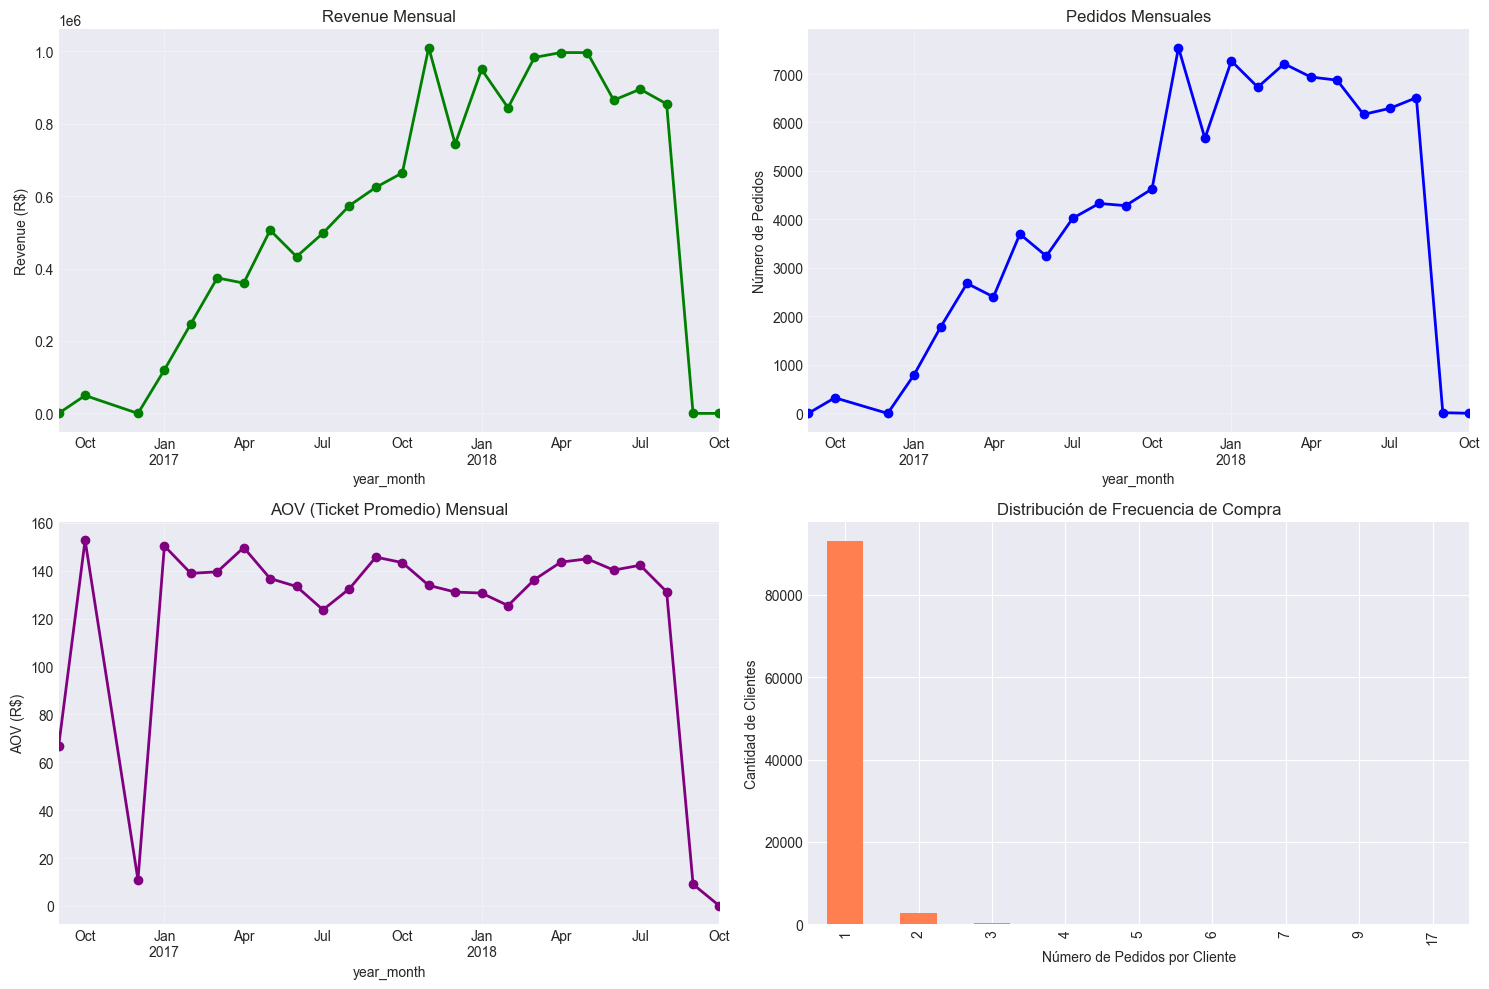


 CRECIMIENTO DE REVENUE: -100.0% (período completo)

 INSIGHTS DE NEGOCIO:
   1. Baja tasa de clientes recurrentes (3.1%) - oportunidad de retención
   2. NPS de 62.4 indica alta satisfacción
   3. AOV de R$ 137.75 - referencia para estrategias de upselling
   4. Tasa de reviews del 99.2% - importante para confianza de compradores


In [13]:
# ============================================================================
# SECCIÓN 11: ANÁLISIS DE NEGOCIO - KPIs Y MÉTRICAS
# ============================================================================

print("\n" + "="*80)
print(" ANÁLISIS DE NEGOCIO - KPIs PRINCIPALES")
print("="*80)

# Preparar datos
df_orders_complete = df_orders.copy()
df_orders_complete['order_purchase_timestamp'] = pd.to_datetime(df_orders_complete['order_purchase_timestamp'])

# KPI 1: Revenue Total
total_revenue = df_items['price'].sum()
print(f"\n REVENUE TOTAL: R$ {total_revenue:,.2f}")

# KPI 2: AOV (Average Order Value)
order_values = df_items.groupby('order_id')['price'].sum()
aov = order_values.mean()
print(f" AOV (Ticket Promedio): R$ {aov:.2f}")

# KPI 3: Número de pedidos y clientes
total_orders = len(df_orders)
total_customers = df_customers['customer_unique_id'].nunique()
print(f" TOTAL DE PEDIDOS: {total_orders:,}")
print(f" TOTAL DE CLIENTES: {total_customers:,}")

# KPI 4: Clientes recurrentes
orders_per_customer = df_orders.merge(df_customers[['customer_id', 'customer_unique_id']], 
                                       on='customer_id').groupby('customer_unique_id').size()
repeat_customers = (orders_per_customer > 1).sum()
repeat_rate = repeat_customers / total_customers * 100
print(f" CLIENTES RECURRENTES: {repeat_customers:,} ({repeat_rate:.2f}%)")

# KPI 5: Productos vendidos
total_products_sold = len(df_items)
unique_products_sold = df_items['product_id'].nunique()
print(f" PRODUCTOS VENDIDOS: {total_products_sold:,} items ({unique_products_sold:,} únicos)")

# KPI 6: Tasa de conversión de reviews
orders_with_review = df_reviews['order_id'].nunique()
review_rate = orders_with_review / total_orders * 100
print(f" TASA DE REVIEWS: {review_rate:.2f}%")

# KPI 7: NPS Simplificado (promotores - detractores)
promoters = (df_reviews['review_score'] >= 4).sum()
detractors = (df_reviews['review_score'] <= 2).sum()
nps = ((promoters - detractors) / len(df_reviews)) * 100
print(f" NPS (simplificado): {nps:.1f}")

# Análisis temporal de revenue
df_orders_complete['year_month'] = df_orders_complete['order_purchase_timestamp'].dt.to_period('M')
monthly_data = df_orders_complete.merge(
    df_items.groupby('order_id')['price'].sum().reset_index(),
    on='order_id', how='left'
)
monthly_revenue = monthly_data.groupby('year_month')['price'].sum()
monthly_orders = df_orders_complete.groupby('year_month').size()

# Visualizaciones de negocio
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Revenue mensual
monthly_revenue.plot(ax=axes[0,0], marker='o', color='green', linewidth=2)
axes[0,0].set_title('Revenue Mensual')
axes[0,0].set_ylabel('Revenue (R$)')
axes[0,0].grid(True, alpha=0.3)

# 2. Pedidos mensuales
monthly_orders.plot(ax=axes[0,1], marker='o', color='blue', linewidth=2)
axes[0,1].set_title('Pedidos Mensuales')
axes[0,1].set_ylabel('Número de Pedidos')
axes[0,1].grid(True, alpha=0.3)

# 3. AOV mensual
monthly_aov = monthly_revenue / monthly_orders
monthly_aov.plot(ax=axes[1,0], marker='o', color='purple', linewidth=2)
axes[1,0].set_title('AOV (Ticket Promedio) Mensual')
axes[1,0].set_ylabel('AOV (R$)')
axes[1,0].grid(True, alpha=0.3)

# 4. Distribución de frecuencia de compra
orders_per_customer.value_counts().sort_index().head(10).plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Distribución de Frecuencia de Compra')
axes[1,1].set_xlabel('Número de Pedidos por Cliente')
axes[1,1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

# Crecimiento
growth_rate = ((monthly_revenue.iloc[-1] - monthly_revenue.iloc[0]) / monthly_revenue.iloc[0] * 100)
print(f"\n CRECIMIENTO DE REVENUE: {growth_rate:.1f}% (período completo)")

print("\n INSIGHTS DE NEGOCIO:")
print(f"   1. Baja tasa de clientes recurrentes ({repeat_rate:.1f}%) - oportunidad de retención")
print(f"   2. NPS de {nps:.1f} indica {'alta' if nps > 50 else 'moderada' if nps > 0 else 'baja'} satisfacción")
print(f"   3. AOV de R$ {aov:.2f} - referencia para estrategias de upselling")
print(f"   4. Tasa de reviews del {review_rate:.1f}% - importante para confianza de compradores")

In [14]:
# ============================================================================
# SECCIÓN 12: RESUMEN EJECUTIVO Y RECOMENDACIONES PARA ETL
# ============================================================================

print("\n" + "="*80)
print(" RESUMEN EJECUTIVO DEL EDA")
print("="*80)

summary_data = {
    'Dataset': list(files.keys()),
    'Filas': [datasets[k].shape[0] for k in files.keys()],
    'Columnas': [datasets[k].shape[1] for k in files.keys()],
    'Nulos': [datasets[k].isnull().sum().sum() for k in files.keys()],
    'Duplicados': [datasets[k].duplicated().sum() for k in files.keys()]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Calidad'] = summary_df.apply(
    lambda x: ' Excelente' if x['Nulos'] == 0 and x['Duplicados'] < 100 
    else ' Buena' if x['Nulos'] < 1000 
    else ' Requiere limpieza', axis=1
)

print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print(" RECOMENDACIONES PARA EL PIPELINE ETL")
print("="*80)

recommendations = """
┌─────────────────────────────────────────────────────────────────────────────┐
│ TRANSFORMACIONES CRÍTICAS                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ 1. ORDERS                                                                   │
│    ✓ Convertir 5 columnas de timestamp a DATETIME                          │
│    ✓ Calcular delivery_time_days y delay_days (métricas derivadas)         │
│    ✓ Mantener nulos en delivered_date (pedidos cancelados/en tránsito)     │
│    ✓ Crear flag is_delayed para análisis de servicio                       │
│                                                                              │
│ 2. ORDER_ITEMS                                                              │
│    ✓ Validar que price > 0 (filtrar anomalías)                             │
│    ✓ Crear columna total_item_value = price + freight_value                │
│    ✓ Agregar order_id para obtener order_total_value                       │
│                                                                              │
│ 3. ORDER_PAYMENTS                                                           │
│    ✓ Agregar por order_id (algunos pedidos tienen múltiples pagos)         │
│    ✓ Crear payment_type_primary (método principal si hay varios)           │
│    ✓ Validar que SUM(payment_value) by order = SUM(price) en items         │
│                                                                              │
│ 4. ORDER_REVIEWS                                                            │
│    ✓ Convertir review_creation_date y review_answer_timestamp a DATETIME   │
│    ✓ Manejar nulos en comment_title y comment_message (usar '')            │
│    ✓ Crear flag has_comment para segmentación                              │
│    ✓ Calcular review_response_time (si aplica)                             │
│                                                                              │
│ 5. PRODUCTS                                                                 │
│    ✓ LEFT JOIN con category_translation para obtener nombres en inglés     │
│    ✓ Imputar nulos en category con 'unknown_category'                      │
│    ✓ Imputar nulos en dimensiones con mediana por categoría                │
│    ✓ Crear columna volume_cm3 = length * width * height                    │
│    ✓ Crear flag has_complete_dimensions                                    │
│                                                                              │
│ 6. GEOLOCATION                                                              │
│    ✓ CRÍTICO: Agregar por zip_code_prefix (promedio lat/lng)               │
│    ✓ Filtrar outliers geográficos (lat/lng fuera de Brasil)                │
│    ✓ Crear tabla derivada geo_aggregated para joins eficientes             │
│                                                                              │
│ 7. CUSTOMERS & SELLERS                                                      │
│    ✓ No requieren transformaciones - datasets limpios                       │
│    ✓ Considerar normalizar nombres de ciudades (mayúsculas inconsistentes) │
├─────────────────────────────────────────────────────────────────────────────┤
│ VALIDACIONES DE CALIDAD                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│ • Validar integridad referencial (FK constraints)                           │
│ • Detectar y loguear outliers extremos en precios                           │
│ • Verificar fechas futuras o pasadas inválidas                              │
│ • Implementar logging de registros rechazados                               │
├─────────────────────────────────────────────────────────────────────────────┤
│ ESTRATEGIA DE CARGA                                                         │
├─────────────────────────────────────────────────────────────────────────────┤
│ • Orden de carga: customers → sellers → products → orders → items →        │
│                    payments → reviews → geolocation                         │
│ • Usar transacciones para mantener consistencia                             │
│ • Crear índices en columnas FK después de la carga                          │
│ • Implementar manejo de errores con rollback                                │
└─────────────────────────────────────────────────────────────────────────────┘
"""

print(recommendations)
print("\n" + "="*80)
print("✅ EDA COMPLETADO")
print("="*80)
print("\n Próximos pasos:")
print("   1. Documentar este análisis para el equipo")
print("   2. Implementar pipeline ETL con las recomendaciones")
print("   3. Crear scripts de validación de calidad")
print("   4. Diseñar dashboards de monitoreo")
print("   5. Establecer proceso de actualización incremental")

print("\n" + "="*80)


 RESUMEN EJECUTIVO DEL EDA

             Dataset   Filas  Columnas  Nulos  Duplicados            Calidad
              orders   99441        11   7873           0  Requiere limpieza
         order_items  112650         7      0           0          Excelente
      order_payments  103886         5      0           0          Excelente
       order_reviews   99224         9 145903           0  Requiere limpieza
           customers   99441         5      0           0          Excelente
            products   32951        10   2450           0  Requiere limpieza
             sellers    3095         4      0           0          Excelente
         geolocation 1000163         5      0      261831              Buena
category_translation      71         2      0           0          Excelente

 RECOMENDACIONES PARA EL PIPELINE ETL

┌─────────────────────────────────────────────────────────────────────────────┐
│ TRANSFORMACIONES CRÍTICAS                                                   │
├